In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [44]:

dataset = pd.read_csv("marketing_campaign.csv", sep=";")

dataset["Income"] = dataset["Income"].fillna(dataset["Income"].median())

dataset = dataset[dataset["Income"] < 200000]

dataset["Total_Spending"] = (
    dataset["MntWines"] +
    dataset["MntFruits"] +
    dataset["MntMeatProducts"] +
    dataset["MntFishProducts"] +
    dataset["MntSweetProducts"] +
    dataset["MntGoldProds"]
)

features = [
    "Income",
    "Recency",
    "Total_Spending",
    "NumWebPurchases",
    "NumStorePurchases"
]

X = dataset[features].values

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

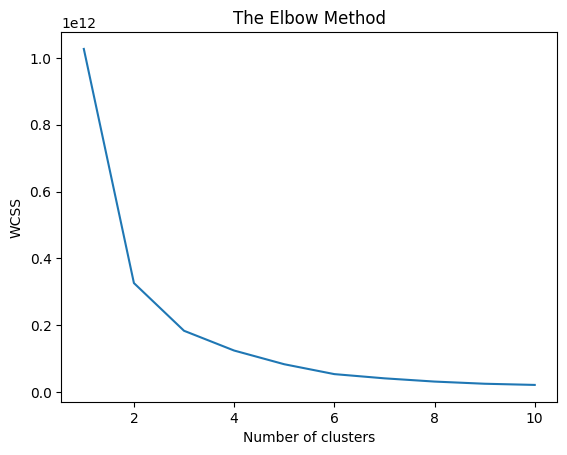

In [46]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [47]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

silhouette_score(X_scaled, y_kmeans)

np.float64(0.4004563529065183)

In [48]:
print(y_kmeans)

[1 1 0 ... 0 0 0]


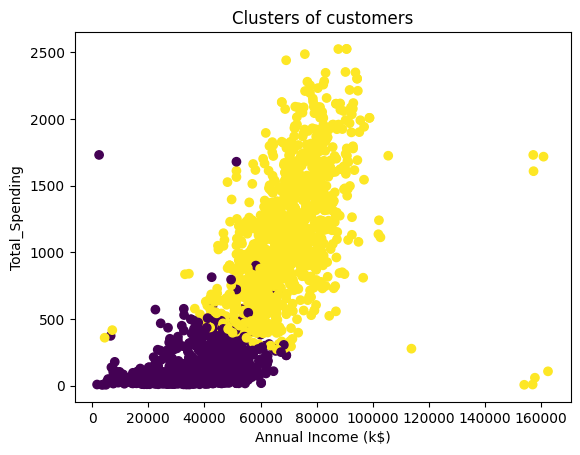

In [49]:
plt.scatter(dataset["Income"], dataset["Total_Spending"], c=y_kmeans)
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Total_Spending')
plt.show()

In [50]:
from sklearn.metrics import silhouette_score

print(silhouette_score(X_scaled, y_kmeans))

0.4004563529065183


In [51]:
print("KMEANS")
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(k, score)

KMEANS
2 0.4004563529065183
3 0.2991105282814551
4 0.26363191755854953
5 0.2692142634777995
6 0.26925735523440036
7 0.26268541309460586
